#**Sales Dynamics and Trend Analysis**

###Total sales per date + overall trend

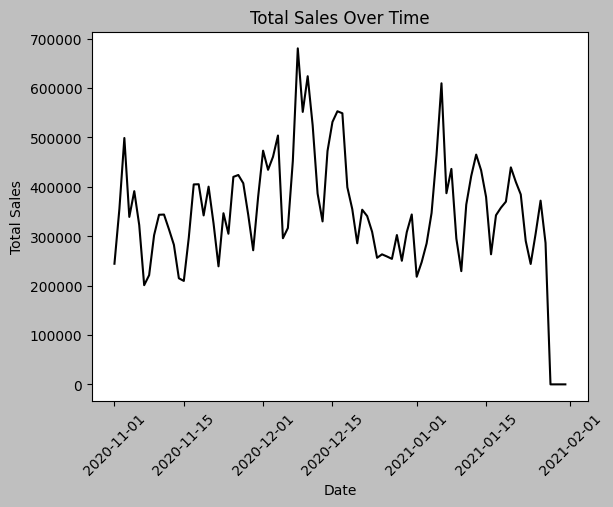

In [ ]:


df['date'] = pd.to_datetime(df['date'])
df['price'] = pd.to_numeric(df['price'], errors='coerce')


daily_sales = df.groupby('date')['price'].sum().reset_index()


plt.figure()
plt.plot(daily_sales['date'], daily_sales['price'])
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


###Seasonality check (7-day rolling average)

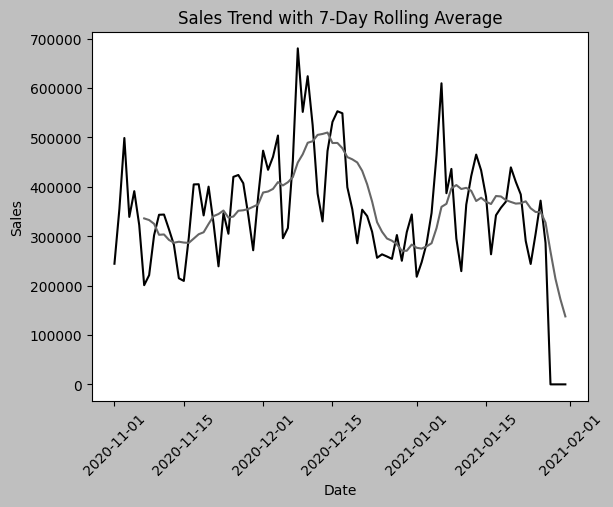

In [ ]:

daily_sales['rolling_7'] = daily_sales['price'].rolling(window=7).mean()

plt.figure()
plt.plot(daily_sales['date'], daily_sales['price'])
plt.plot(daily_sales['date'], daily_sales['rolling_7'])
plt.title("Sales Trend with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()


###Sales dynamics by continent (America, Asia, Europe)

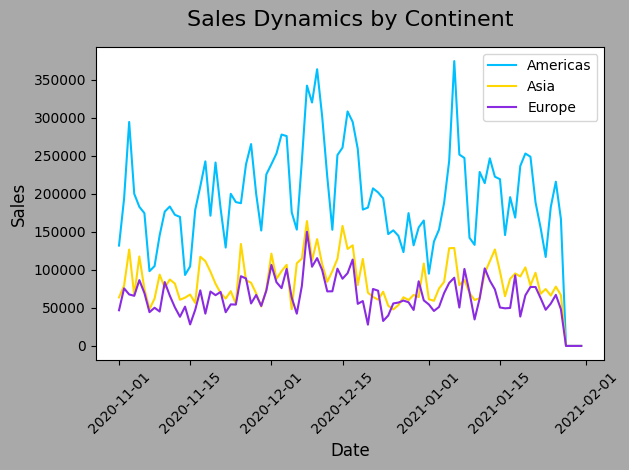

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

line_colors = ['#00BFFF', '#FFD700', '#8A2BE2']

continents = ['Americas', 'Asia', 'Europe']
df_cont = df[df['continent'].isin(continents)]
continent_sales = df_cont.groupby(['date','continent'])['price'].sum().reset_index()

plt.figure(facecolor='#A9A9A9')
ax = plt.gca()
ax.set_facecolor('white')

for i, continent in enumerate(continents):
    data = continent_sales[continent_sales['continent'] == continent]
    plt.plot(
        data['date'],
        data['price'],
        label=continent,
        color=line_colors[i],
        linewidth=1.5
    )

plt.title("Sales Dynamics by Continent", fontsize=16, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Sales", fontsize=12)

plt.xticks(rotation=45)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')

plt.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

###Sales dynamics by traffic channel

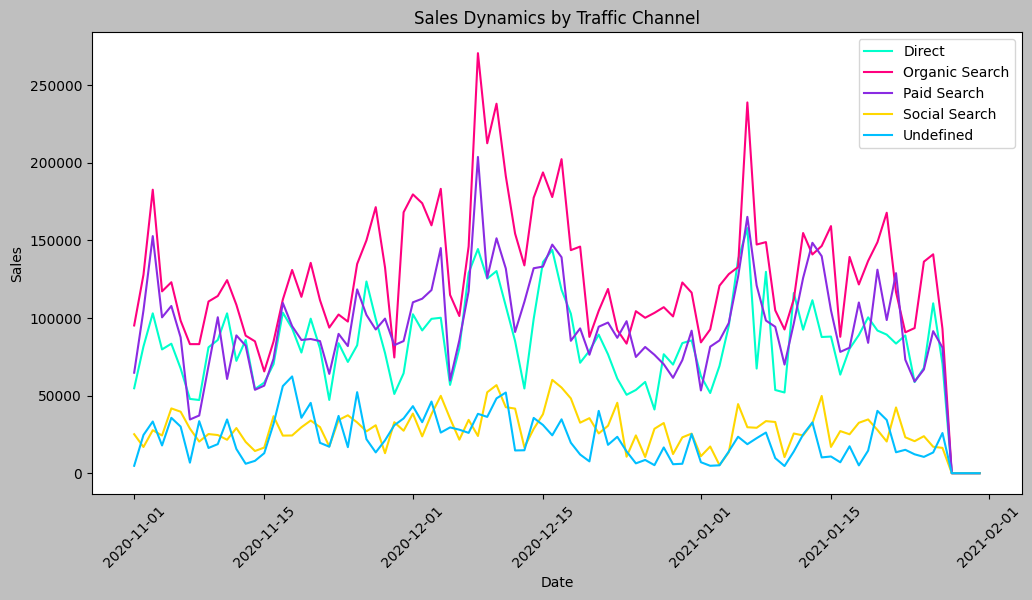

In [ ]:
import matplotlib.pyplot as plt

colors = ['#00FFCC', '#FF007F', '#8A2BE2', '#FFD700', '#00BFFF']

channel_sales = df.groupby(['date','traffic_channel'])['price'].sum().reset_index()

plt.figure(figsize=(12, 6))


for i, channel in enumerate(channel_sales['traffic_channel'].unique()):
    data = channel_sales[channel_sales['traffic_channel'] == channel]
    plt.plot(data['date'], data['price'], label=channel, color=colors[i % len(colors)])

plt.title("Sales Dynamics by Traffic Channel")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()


###Sales dynamics by device type

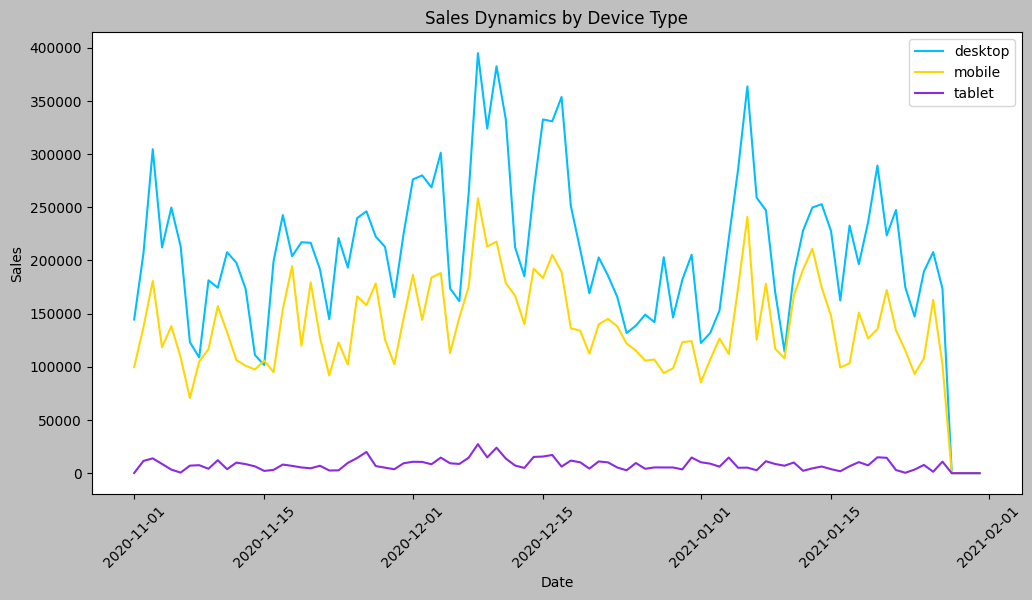

In [ ]:
device_sales = df.groupby(['date', 'device'])['price'].sum().reset_index()
lines_colors = ['#00BFFF', '#FFD700', '#8A2BE2']
plt.figure(figsize=(12, 6))

for i, device in enumerate(device_sales['device'].unique()):
    data = device_sales[device_sales['device'] == device]
    plt.plot(data['date'], data['price'], label=device, color=lines_colors[i % len(lines_colors)])

plt.title("Sales Dynamics by Device Type")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.xticks(rotation=45)
plt.show()